# RL over cLATb for SPECK (ε = 0.25)

Trains a tabular **Q-learning** agent using the **cLATb** structure: `cLATb: { u: { v: { w: bd }}}`.
- **Reward** = `log₂(|bias|)` (piling-up).
- **State** = `(u, v)`, **Action** = `w`.
- **Transition** (SPECK): `u' = ROR(w, α)`, `v' = ROL(v, β) XOR w`.
- **Exploration**: ε-greedy with **ε = 0.1**.

Works in **Colab** (file upload / Drive), Kaggle, or local Jupyter.


In [1]:
import sys
import os, gzip, pickle, math, random
from collections import defaultdict
from typing import Dict, Tuple, List, Optional, Iterable

from collections import defaultdict
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
SEED = 1337
random.seed(SEED)
np.random.seed(SEED)



## Auto detect the environment and locate and load the cLAT

In [2]:


DEFAULT_NAME = "clat_speck_pruned.pkl.gz"

ENV = {
    "colab": "google.colab" in sys.modules,
    "kaggle": bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE")),
    "vscode": bool(os.environ.get("VSCODE_PID")),
}
ENV["jupyter_local"] = not any(ENV.values())

def candidate_paths():
    cands = []
    if "CLAT_PATH" in globals():
        cands.append(globals()["CLAT_PATH"])
    cands += [DEFAULT_NAME, f"./{DEFAULT_NAME}"]
    if ENV["colab"]:
        cands += [f"/content/{DEFAULT_NAME}",
                  f"/content/drive/MyDrive/{DEFAULT_NAME}",
                  f"/content/drive/MyDrive/Tesis/{DEFAULT_NAME}"]
    if ENV["kaggle"]:
        cands += [f"/kaggle/working/{DEFAULT_NAME}", f"/kaggle/input/{DEFAULT_NAME}"]
    return cands

def find_first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

cands = candidate_paths()
path = find_first_existing(cands)

# Colab: si no aparece, permitir upload o Drive
if not path and ENV["colab"]:
    try:
        from google.colab import files, drive  # type: ignore
        print("File not found. Choose one:")
        print("  a) Upload now (files.upload)")
        print("  b) Mount Drive and use /content/drive/MyDrive/...")
        choice = "a"  # cambia a "b" si prefieres Drive
        if choice.lower() == "a":
            up = files.upload()
            if up:
                path = list(up.keys())[0]
        else:
            drive.mount("/content/drive")
            path = f"/content/drive/MyDrive/{DEFAULT_NAME}"
    except Exception as e:
        print("Upload/Drive not available:", e)

if not path:
    # glob needs to be imported as well
    import glob
    g = glob.glob(f"**/{DEFAULT_NAME}", recursive=True)
    if g: path = g[0]

if not path:
    raise FileNotFoundError("Could not find the cLAT pickle. "
                            "Place 'clat_speck.pkl.gz' next to this notebook or set CLAT_PATH.\n"
                            "Tried:\n" + "\n".join(cands))

print("ENV:", ENV)
print("Using path:", os.path.abspath(path))

# Cargar pickle (fallback de encoding)
try:
    with gzip.open(path, "rb") as f:
        clat_obj = pickle.load(f)
except Exception:
    with gzip.open(path, "rb") as f:
        clat_obj = pickle.load(f, encoding="latin1")

print("Loaded object type:", type(clat_obj))

# Seleccionar payload que contiene 'cLATb'
if isinstance(clat_obj, dict) and "cLATb" in clat_obj:
    payload = clat_obj
elif isinstance(clat_obj, dict) and "payload" in clat_obj and isinstance(clat_obj["payload"], dict) and "cLATb" in clat_obj["payload"]:
    payload = clat_obj["payload"]
else:
    candidate = None
    if isinstance(clat_obj, dict):
        for v in clat_obj.values():
            if isinstance(v, dict) and "cLATb" in v:
                candidate = v; break
    if candidate is None:
        raise KeyError("Could not find 'cLATb' in the loaded pickle. Inspect the structure and adjust.")
    payload = candidate

assert "cLATb" in payload, "Payload does not contain 'cLATb'."
print("Found keys in payload:", list(payload.keys()))

ENV: {'colab': True, 'kaggle': False, 'vscode': False, 'jupyter_local': False}
Using path: /content/clat_speck_pruned.pkl.gz
Loaded object type: <class 'dict'>
Found keys in payload: ['m', 'cLATmin', 'cLATN', 'cLATu', 'cLATw', 'cLATb']


## SPECK-32 implementation

In [3]:

class Speck:
    def __init__(self, n_rounds=22, word_size=16, use_key_schedule=True, alpha=7, beta=2, m=4):
        self.n_rounds = int(n_rounds)
        self.word_size = int(word_size)
        self.n_words = 2
        self.n_main_key_words = int(m)
        self.n_round_key_words = 1
        self.use_key_schedule = bool(use_key_schedule)
        self.alpha = int(alpha)
        self.beta  = int(beta)
        self.mask_val = (1 << self.word_size) - 1
        # tipos (compat con np):
        self.main_key_word_dtype = np.uint16 if self.word_size == 16 else np.uint32
        self.round_keys = None  # np.array shape (R,1) con palabras de subllave

    # --- Rotaciones ---
    def rol(self, x, r):
        n = self.word_size
        return ((x << r) & ((1 << n) - 1)) | (x >> (n - r))

    def ror(self, x, r):
        n = self.word_size
        return (x >> r) | ((x << (self.word_size - r)) & ((1 << self.word_size) - 1))

    # --- Paridad ---
    @staticmethod
    def parity(x: int) -> int:
        return int(x).bit_count() & 1

    # ============ Ronda ============
    def encrypt_one_round(self, p, k, rc=None):
        """Una ronda: (x,y) -> (x',y'). k es [kw] o (kw,)."""
        x, y = int(p[0]), int(p[1])
        x = self.ror(x, self.alpha)
        x = (x + y) & self.mask_val
        x = x ^ int(k[0])
        y = self.rol(y, self.beta)
        y = y ^ x
        return x, y

    def decrypt_one_round(self, c, k, rc=None):
        """Inversa de una ronda: (x',y') -> (x,y)."""
        x, y = int(c[0]), int(c[1])
        y = y ^ x
        y = self.ror(y, self.beta)
        x = x ^ int(k[0])
        x = (x - y) & self.mask_val
        x = self.rol(x, self.alpha)
        return x, y

    # ============ Full/Reducido ============
    def encrypt(self, plaintext, rounds=None, key=None, trace=False):
        R = self.n_rounds if rounds is None else int(rounds)
        x, y = int(plaintext[0]), int(plaintext[1])
        rk = self.key_schedule(key) if (key is not None) else self.round_keys
        if rk is None:
            raise ValueError("round_keys no inicializadas. Llama key_schedule(key) o pasa key=")
        out = [(x, y)] if trace else None
        for r in range(R):
            x, y = self.encrypt_one_round((x, y), rk[r])
            if trace:
                out.append((x, y))
        return out if trace else (x, y)

    def decrypt(self, ciphertext, rounds=None, key=None, trace=False):
        R = self.n_rounds if rounds is None else int(rounds)
        x, y = int(ciphertext[0]), int(ciphertext[1])
        rk = self.key_schedule(key) if (key is not None) else self.round_keys
        if rk is None:
            raise ValueError("round_keys no inicializadas. Llama key_schedule(key) o pasa key=")
        rk = rk[:R]
        out = [(x, y)] if trace else None
        for r in range(R - 1, -1, -1):
            x, y = self.decrypt_one_round((x, y), rk[r])
            if trace:
                out.append((x, y))
        return out if trace else (x, y)

    # ============ Puntos internos última ronda ============
    def partial_decrypt_last_round(self, C, k_r, stop_at="before_add"):
        """
        Invierte selectivamente la última ronda sobre C=(x',y') usando k_r=[kw].
        stop_at:
          - "after_xor_y"     -> (x', y^)
          - "after_ror_beta"  -> (x', y~~)
          - "after_xor_k"     -> (x^, y~~)
          - "before_add"      -> (x~~, y~~)
          - "after_rol_alpha" -> (x, y) original antes de la última ronda
        """
        x1, y1 = int(C[0]), int(C[1])
        # y = y ^ x
        y = y1 ^ x1
        if stop_at == "after_xor_y":
            return x1, y
        # y = ROR(y, beta)
        y = self.ror(y, self.beta)
        if stop_at == "after_ror_beta":
            return x1, y
        # x = x ^ k
        x = x1 ^ int(k_r[0])
        if stop_at == "after_xor_k":
            return x, y
        # x = (x - y)
        x = (x - y) & self.mask_val
        if stop_at == "before_add":
            return x, y
        # x = ROL(x, alpha)
        x = self.rol(x, self.alpha)
        if stop_at == "after_rol_alpha":
            return x, y
        raise ValueError(f"stop_at desconocido: {stop_at}")

    # ============ Key schedule ============
    def key_schedule(self, key):
        """
        Devuelve np.array shape (n_rounds, 1) con las subllaves.
        'key' como np.array shape (m,1) o lista de m palabras.
        """
        if key is None:
            return self.round_keys
        if isinstance(key, (list, tuple)):
            key = np.array(key, dtype=self.main_key_word_dtype)[:, np.newaxis]
        assert key.shape[0] == self.n_main_key_words, "m (número de palabras de clave) no coincide"
        ks = [0 for _ in range(self.n_rounds)]
        ks[0] = int(key[len(key)-1][0])  # última palabra como k0
        L = list(reversed([int(key[i][0]) for i in range(len(key)-1)]))  # resto invertidas
        for i in range(self.n_rounds - 1):
            L[i % (len(L))], ks[i+1] = self.encrypt_one_round((L[i % len(L)], ks[i]), [i])
        self.round_keys = np.array(ks, dtype=self.main_key_word_dtype)[:, np.newaxis]
        return self.round_keys

    # ============ Correlación exacta de UNA suma (DP de carry) ============
    @staticmethod
    def _corr_addition(a_mask, b_mask, g_mask, n):
        # correlación exacta en [-1,1] para <a,x> ⊕ <b,y> ⊕ <g, x+y>
        A = [(a_mask>>i)&1 for i in range(n)]
        B = [(b_mask>>i)&1 for i in range(n)]
        G = [(g_mask>>i)&1 for i in range(n)]
        DP0, DP1 = 1, 0  # carry_in = 0/1
        for i in range(n):
            nDP0 = nDP1 = 0
            for cin in (0,1):
                base = DP0 if cin == 0 else DP1
                if base == 0:
                    continue
                for x in (0,1):
                    for y in (0,1):
                        cout = (x & y) | (x & cin) | (y & cin)
                        e = ((A[i]^G[i]) & x) ^ ((B[i]^G[i]) & y) ^ (G[i] & cin)
                        if cout == 0:
                            nDP0 += base if e == 0 else -base
                        else:
                            nDP1 += base if e == 0 else -base
            DP0, DP1 = nDP0, nDP1
        return (DP0 + DP1) / (2**(2*n))

    def corr_one_round_masks(self, ax, ay, gx, gy_prime=0):
        """
        Correlación de 1 ronda con máscaras (teórica):
        ax, ay: máscaras de entrada; gx: máscara en x' (XOR k no cambia corr);
        gy_prime: máscara en y' (opcional).
        """
        n = self.word_size
        a_for_adder = self.rol(ax, self.alpha)
        b_for_adder = ay ^ self.ror(gy_prime, self.beta)
        g_for_adder = gx
        return self._corr_addition(a_for_adder, b_for_adder, g_for_adder, n)

    # ===================================================
    #  (1) Herramientas manuales para triples (u,v,w)
    # ===================================================

    def corr_weight_add(self, u, v, w):
        """
        Devuelve Cw (entero) si (u,v,w) es válida para la suma n-bit; None si no lo es.
        Filtro de validez usa máscara Z (bits con acarreo).
        """
        n = self.word_size
        A = u ^ v
        B = u ^ w
        C = u ^ v ^ w
        cw = 0
        Z  = 0
        carry = 0
        for i in range(n):  # LSB→MSB
            cbit = (C >> i) & 1
            carry = (cbit + carry) & 1
            if carry:
                cw += 1
                Z |= (1 << i)
        if (A & ~Z) != 0:
            return None
        if (B & ~Z) != 0:
            return None
        return cw

    def next_round_masks(self, GX_i, GY_i, w):
        """
        Dadas GX_i, GY_i y elección de w = GX_{i+1}, produce:
          triple=(u,v,w)  y  siguiente estado (GX_{i+1}, GY_{i+1}).
        Reglas SPECK:
          u = ROR(GX_i, alpha),  v = GY_i,
          GY_{i+1} = ROL(GY_i, beta) ^ GX_{i+1}.
        """
        u = self.ror(GX_i, self.alpha)
        v = GY_i
        GX_ip1 = w
        GY_ip1 = self.rol(GY_i, self.beta) ^ GX_ip1
        return (u, v, GX_ip1), (GX_ip1, GY_ip1)

    def trail_weight(self, triples):
        total = 0
        for (u, v, w) in triples:
            cw = self.corr_weight_add(u, v, w)
            if cw is None:
                return None
            total += cw
        return total  # |corr| = 2^{-total}

    def greedy_trail(self, GX0, GY0, rounds=6, force_w_last=None, allow_trivial=False,
                 consider_three_bits_if_empty=False):
      """
      Greedy simple pero EXHAUSTIVO en 1–2 bits por ronda.
      - force_w_last: fija w en la última ronda (útil para anclar un gx).
      - allow_trivial: permite u=v=w (Cw=0). Déjalo False salvo diagnóstico.
      - consider_three_bits_if_empty: si no hay ningún 1–2 bits válido, prueba 3 bits.
      Devuelve (triples, GX_list, GY_list, Cw_total) o (None, GX, GY, None) si falla.
      """
      n = self.word_size
      M = self.mask_val
      GX = [0] * (rounds + 1)
      GY = [0] * (rounds + 1)
      GX[0], GY[0] = (int(GX0) & M), (int(GY0) & M)

      triples = []
      total_cw = 0

      for r in range(rounds):
          u = self.ror(GX[r], self.alpha) & M
          v = GY[r] & M

          # Construye lista completa de 1–2 bits
          cand_ws = []
          for i in range(n):
              cand_ws.append((1 << i) & M)
          for i in range(n):
              for j in range(i+1, n):
                  cand_ws.append(((1 << i) | (1 << j)) & M)

          # Si es la última ronda y se pide ancla, solo ese w
          if (force_w_last is not None) and (r == rounds - 1):
              cand_ws = [int(force_w_last) & M]

          best = None
          best_cw = None

          for w in cand_ws:
              triple = (u, v, w)
              cw = self.corr_weight_add(*triple)
              if cw is None:
                  continue
              if (not allow_trivial) and (u == v == w):
                  continue
              if (best_cw is None) or (cw < best_cw):
                  best_cw = cw
                  best = (triple, w)

          # Si no hubo ningún 1–2 bits válido, intenta 3 bits (opcional)
          if (best is None) and consider_three_bits_if_empty:
              for i in range(n):
                  for j in range(i+1, n):
                      for k in range(j+1, n):
                          w = ((1<<i)|(1<<j)|(1<<k)) & M
                          triple = (u, v, w)
                          cw = self.corr_weight_add(*triple)
                          if cw is None:
                              continue
                          if (not allow_trivial) and (u == v == w):
                              continue
                          if (best_cw is None) or (cw < best_cw):
                              best_cw = cw
                              best = (triple, w)

          if best is None:
              return None, GX, GY, None

          triple, w_best = best
          GX[r+1] = w_best
          GY[r+1] = (self.rol(GY[r], self.beta) ^ w_best) & M
          triples.append(triple)
          total_cw += best_cw

      return triples, GX, GY, total_cw

    def gen_pairs(self, Npairs, rounds=None, seed=1234):
        """Genera Npairs de (P,C) cifrando con las round_keys cargadas."""
        if self.round_keys is None:
            raise ValueError("round_keys no inicializadas. Llama key_schedule(key)." )
        rng = np.random.default_rng(seed)
        n = self.word_size
        m = (1 << n) - 1
        R = self.n_rounds if rounds is None else int(rounds)
        out = []
        for _ in range(int(Npairs)):
            P = (int(rng.integers(0, 1<<n)) & m, int(rng.integers(0, 1<<n)) & m)
            C = self.encrypt(P, rounds=R, key=None, trace=False)
            out.append((P, C))
        return out

    def _mask_bit_positions(self, w):
        n = self.word_size
        return [i for i in range(n) if (w >> i) & 1]

    def matsui1_last_round_score_keyed(self, pairs, ax, ay, gx, gy_prime=0, w_last=None):
        """Matsui-1 'keyed' para la ÚLTIMA ronda"""
        n = self.word_size

        if w_last is None:
            w_last = gx
        if w_last == 0:
            raise ValueError("w_last es 0: no hay bits de clave para adivinar.")

        bitpos = [i for i in range(n) if (w_last >> i) & 1]
        scores = {}

        for g in range(1 << len(bitpos)):
            key_guess = 0
            for j, pos in enumerate(bitpos):
                if (g >> j) & 1:
                    key_guess |= (1 << pos)

            bias_counter = 0
            for (_, C) in pairs:
                x1, y1 = C  # ciphertext (x',y')
                x, y = self.partial_decrypt_last_round(C, [key_guess], stop_at="after_rol_alpha")

                lhs = ( self.parity(x  & ax)
                      ^ self.parity(y  & ay)
                      ^ self.parity(x1 & gx)
                      ^ self.parity(y1 & gy_prime) )
                bias_counter += (lhs == 0) - (lhs == 1)

            scores[key_guess] = abs(bias_counter)

        ranked = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)
        return ranked

    def estimate_bias_of_triple(self, u, v, w, samples=200_000, seed=2025):
        """Muestreo simple para ver p y |eps| de una triple (u,v,w) n-bit."""
        rng = np.random.default_rng(seed)
        n = self.word_size; m = (1<<n)-1
        cnt = 0
        for _ in range(samples):
            X = int(rng.integers(0, 1<<n)) & m
            Y = int(rng.integers(0, 1<<n)) & m
            Z = (X + Y) & m
            lhs = (self.parity(X & u) ^ self.parity(Y & v) ^ self.parity(Z & w))
            cnt += (lhs == 0)
        p = cnt / samples
        eps = abs(p - 0.5)
        return p, eps

    @staticmethod
    def _bits_set_(x: int, n: int):
        """Devuelve posiciones 0..n-1 con bit=1 en x."""
        return [i for i in range(n) if (x >> i) & 1]

    @staticmethod
    def _gen_w_candidates_(n: int, u: int, v: int, max_two_bit_pairs: int | None = None):
        """Genera candidatos w priorizando cercanía a u y v."""
        seen = set()
        order = []

        bu = Speck._bits_set_(u, n)
        bv = Speck._bits_set_(v, n)
        allpos = list(range(n))

        # 1-bit: u -> v -> resto
        for pos in bu + [p for p in bv if p not in bu] + [p for p in allpos if (p not in bu) and (p not in bv)]:
            w = 1 << pos
            if w not in seen:
                seen.add(w); order.append(w)

        # 2-bits cercanos
        pairs = []
        for i in range(len(bu)):
            for j in range(i+1, len(bu)):
                pairs.append((bu[i], bu[j]))
        for i in range(len(bv)):
            for j in range(i+1, len(bv)):
                pairs.append((bv[i], bv[j]))
        for i in bu:
            for j in bv:
                if i != j:
                    a, b = (i, j) if i < j else (j, i)
                    pairs.append((a, b))
        for i in range(n):
            for j in range(i+1, n):
                pairs.append((i, j))

        seen_pair = set()
        two_bit_ws = []
        for i, j in pairs:
            key = (i, j)
            if key in seen_pair:
                continue
            seen_pair.add(key)
            two_bit_ws.append((1 << i) | (1 << j))
            if (max_two_bit_pairs is not None) and (len(two_bit_ws) >= max_two_bit_pairs):
                break

        for w in two_bit_ws:
            if w not in seen:
                seen.add(w); order.append(w)

        return order


## Build graph from the loaded cLAT

In [4]:
clatb = payload["cLATb"]

# ---------- helpers ----------
def _to_int_mask(x: Any) -> int:
    if isinstance(x, (int, np.integer)):
        return int(x)
    s = str(x).strip()
    if s.startswith("(") and s.endswith(")"):
        s = s[1:-1]
    try:
        return int(s, 0)          # soporta "0x..."
    except Exception:
        return int(float(s))

def _bias_from_cw(cw: Any) -> float:
    # cw es peso de correlación → |bias| = 2^{-cw}
    return float(2.0 ** (-float(cw)))

def _best_bias_from_dicts(dicts: Iterable[dict]) -> float:
    """
    Recibe una colección de dicts tipo {'conn': a, 'cw': 8} o {'bias': 0.03125}
    y devuelve el "mejor" bias:
      - si hay 'cw': el menor cw (sesgo más fuerte)
      - si hay 'bias'/'corr': el de mayor |bias|
    """
    best = None
    have_cw = any('cw' in d for d in dicts)

    if have_cw:
        # elegir el menor cw
        min_cw = None
        for d in dicts:
            if 'cw' in d:
                cw = float(d['cw'])
                if (min_cw is None) or (cw < min_cw):
                    min_cw = cw
        if min_cw is not None:
            return _bias_from_cw(min_cw)

    # si no hubo 'cw', intenta por bias/corr y usa mayor |bias|
    for d in dicts:
        if 'bias' in d:
            val = float(d['bias'])
        elif 'corr' in d:
            val = float(d['corr'])
        elif 'epsilon' in d or 'eps' in d or 'e' in d or 'c' in d:
            for k in ('epsilon', 'eps', 'e', 'c'):
                if k in d:
                    val = float(d[k]); break
        else:
            continue
        if (best is None) or (abs(val) > abs(best)):
            best = val

    if best is None:
        raise ValueError("No se pudo determinar bias en dicts de acciones.")
    return float(best)

def _extract_bias(bd: Any) -> float:
    """
    Acepta:
      - escalar (int/float/np.*)
      - dict plano con 'bias'/'corr' o con 'cw'
      - dict de acciones: {0: {...}, 1: {...}}  -> elige mejor acción
    """
    # escalar
    if isinstance(bd, (int, float, np.floating, np.integer)):
        return float(bd)

    if not isinstance(bd, dict):
        raise ValueError(f"Unexpected 'bd' type: {type(bd)} → {bd!r}")

    # --- caso: dict de acciones (values también son dicts con cw/bias) ---
    if bd and all(isinstance(v, dict) for v in bd.values()) and \
       any(('cw' in v) or ('bias' in v) or ('corr' in v) or ('epsilon' in v) or ('eps' in v) or ('e' in v) or ('c' in v)
           for v in bd.values()):
        return _best_bias_from_dicts(bd.values())

    # --- caso: dict plano con cw/bias ---
    for k in ("bias", "corr", "epsilon", "eps", "e", "c"):
        if k in bd:
            return float(bd[k])
    for k in ("cw", "weight", "cweight", "corr_weight"):
        if k in bd:
            return _bias_from_cw(bd[k])

    # último recurso: primer valor numérico
    for v in bd.values():
        if isinstance(v, (int, float, np.floating, np.integer)):
            return float(v)

    raise ValueError(f"Could not extract bias from bd={bd}")

# ---------- construcción de edges ----------
def build_edges_from_payload(payload: dict):
    # Fuente principal
    src = payload["cLATb"] if "cLATb" in payload else payload["cLATw"]

    edges = defaultdict(list)
    count = 0

    for u, vd in src.items():
        uu = _to_int_mask(u)
        for v, wd in vd.items():
            vv = _to_int_mask(v)

            # wd es mapa w -> bd (bd puede ser: escalar, dict plano, o dict de acciones)
            if isinstance(wd, dict):
                for w, bd in wd.items():
                    ww = _to_int_mask(w)
                    bias = _extract_bias(bd)   # <-- ahora soporta dict de acciones
                    edges[(uu, vv)].append((ww, float(bias)))
                    count += 1
            else:
                # Raro pero lo manejamos: v → bias directo (sin w), asumimos w=0
                ww = 0
                bias = _extract_bias(wd)
                edges[(uu, vv)].append((ww, float(bias)))
                count += 1

    return edges, count

# ---------- uso ----------
edges, count = build_edges_from_payload(payload)
print(f"Built edges for {len(edges)} (u,v) states with {count} transitions total.")
peek_key = next(iter(edges))
print("Sample state:", peek_key, "->", edges[peek_key][:3])


Built edges for 65536 (u,v) states with 780994 transitions total.
Sample state: (0, 0) -> [(0, 0.00390625), (1, 0.00390625), (2, 0.00390625)]


In [5]:

def _to_int(x):
    if isinstance(x, (int, np.integer)): return int(x)
    return int(str(x), 0)

def _bias_from_cw(cw, cw_on="epsilon"):
    cw = float(cw)
    return 2.0 ** (-(cw + 1.0)) if cw_on == "epsilon" else 2.0 ** (-cw)

def build_edges_with_b(payload, cw_on="epsilon"):
    # Usa cLATb porque es la que contiene {conn, cw} indexado por 'b'
    src = payload["cLATb"]
    edges_b = defaultdict(list)   # (u,v,b) -> [(w, bias, b_next)]
    count = 0
    for u, vd in src.items():
        uu = _to_int(u)
        for v, wd in vd.items():
            vv = _to_int(v)
            for w, bd in wd.items():
                ww = _to_int(w)
                # bd es dict indexado por b: {0:{conn,cw}, 1:{conn,cw}} (a veces falta uno)
                for b_key, rec in bd.items():
                    b = int(b_key)
                    cw = rec.get("cw", payload["m"])
                    conn = int(rec.get("conn", 0))  # b_next
                    bias = _bias_from_cw(cw, cw_on=cw_on)
                    edges_b[(uu, vv, b)].append((ww, float(bias), conn))
                    count += 1
    return edges_b, count

edges_b, count = build_edges_with_b(payload, cw_on="epsilon")
print(f"Built edges_b for {len(edges_b)} (u,v,b) states with {count} transitions.")
peek = next(iter(edges_b))
print("Sample:", peek, "->", edges_b[peek][:3])


Built edges_b for 87382 (u,v,b) states with 781250 transitions.
Sample: (0, 0, 0) -> [(0, 0.001953125, 0)]


## Environment

In [6]:
speck = Speck(n_rounds=22, word_size=16, alpha=7, beta=2, m=4)
WORD_BITS = speck.word_size
ALPHA     = speck.alpha
BETA      = speck.beta
MASK      = speck.mask_val

# ========= Utils =========
import math, random
from collections import defaultdict

def _get(d, k):  # soporta claves int/str en el pickle
    return d[k] if k in d else d[str(k)]

def _bias_from_cw(cw: float) -> float:
    # si cw es sobre correlación: |ε|=2^{-cw} ⇒ |bias|=|ε|/2 = 2^{-(cw+1)}
    return 2.0 ** (-(float(cw) + 1.0))


# ========= Entorno jerárquico 8→16 =========
# Estado: (uH, uL, vH, vL, b, phase)  con phase∈{0,1} (elige wH y luego wL)
# Acción: w8 (0..255)
# Recompensa por ronda: |bias| con bias = 2^{-(cwH+cwL+1)}
# === reemplaza tu clase por esta versión (cambia solo reset + helper) ===
class EnvHier8to16:
    def __init__(self, payload: dict, speck16, rounds: int = 6,
                 reward_mode: str = "abs", carry: str = "zero"):
        self.P = payload; self.S = speck16
        self.R = int(rounds); self.reward_mode = reward_mode
        assert carry in ("zero","propagate")
        self.carry = carry
        self._rng = random.Random()
        self.reset()

    def _get(self, d, k):
        return d[k] if k in d else d[str(k)]

    def _row_for(self, u: int, v: int):
        try:
            return self._get(self._get(self.P["cLATb"], u), v)
        except Exception:
            return {}

    def _sample_valid_state(self, trials=5000):
        """Devuelve (uH,uL,vH,vL,b,phase) con al menos 1 acción válida en phase=0."""
        cN = self.P["cLATN"]; cU = self.P["cLATu"]; cW = self.P["cLATw"]; cB = self.P["cLATb"]
        def get(d,k): return d[k] if k in d else d[str(k)]
        for _ in range(trials):
            v16 = self._rng.randrange(1<<16)
            vH, vL = (v16>>8)&0xFF, v16&0xFF
            b = 0  # arrancamos con b_in=0

            # Elegir (uH, wH) válidos para (vH,b=0)
            nh = get(get(cN, vH), b)
            if not nh:
                continue
            # coge un cw al azar y uno de sus índices
            cwHk = self._rng.choice(list(nh.keys()))
            uH_list = get(get(get(cU, vH), b), cwHk)
            wH_list = get(get(get(cW, vH), b), cwHk)
            idxH = self._rng.randrange(len(uH_list))
            uH = int(uH_list[idxH]); wH = int(wH_list[idxH])

            # bH (carry entre mitades)
            bH = int(get(get(get(get(cB, uH), vH), wH), b)["conn"])

            # Chequear que exista al menos un wL válido para (uL, vL, bH)
            nl = get(get(cN, vL), bH)
            if not nl:
                continue
            cwLk = self._rng.choice(list(nl.keys()))
            uL_list = get(get(get(cU, vL), bH), cwLk)
            if not uL_list:
                continue
            uL = int(self._rng.choice(list(uL_list)))

            # ¡Listo! hay acción en phase=0
            return (uH, uL, vH, vL, 0, 0)
        # Si no encontramos en trials, cae a (0,0,0,0) pero con phase=0 sin acciones
        return (0,0,0,0,0,0)

    # --- API ---
    def reset(self, init_state=None):
        self.t = 0
        if init_state is None:
            self.uH, self.uL, self.vH, self.vL, self.b, self.phase = self._sample_valid_state()
        else:
            self.uH, self.uL, self.vH, self.vL, self.b, self.phase = init_state
        self.partial = None
        return (self.uH, self.uL, self.vH, self.vL, self.b, self.phase)

    def actions(self, s=None):
        uH,uL,vH,vL,b,phase = (s if s is not None else
                               (self.uH,self.uL,self.vH,self.vL,self.b,self.phase))
        if phase == 0:
            row = self._row_for(uH, vH)
            return [w for w, bd in row.items() if b in bd]
        else:
            assert self.partial is not None, "Fase baja sin parcial"
            bH = self.partial[2]
            row = self._row_for(uL, vL)
            return [w for w, bd in row.items() if bH in bd]

    def step(self, w: int):
        if self.phase == 0:
            bd = self._row_for(self.uH, self.vH).get(w, {})
            rec = bd.get(self.b)
            if rec is None:
                return (self.uH,self.uL,self.vH,self.vL,self.b,self.phase), -1e2, True, {"error":"invalid_action_hi"}
            cwH = int(rec["cw"]); bH = int(rec["conn"])
            self.partial = (w, cwH, bH)
            self.phase = 1
            return (self.uH,self.uL,self.vH,self.vL,self.b,self.phase), 0.0, False, {"phase":"lo"}

        # phase == 1
        wH, cwH, bH = self.partial
        bd = self._row_for(self.uL, self.vL).get(w, {})
        rec = bd.get(bH)
        if rec is None:
            return (self.uH,self.uL,self.vH,self.vL,self.b,self.phase), -1e2, True, {"error":"invalid_action_lo"}

        cwL = int(rec["cw"]); cw = cwH + cwL
        bias = 2.0 ** (-(float(cw) + 1.0))
        reward = abs(bias) if self.reward_mode == "abs" else math.log2(max(abs(bias), 1e-300))

        w16 = ((wH & 0xFF) << 8) | (w & 0xFF)
        v16 = ((self.vH & 0xFF) << 8) | (self.vL & 0xFF)
        up = self.S.ror(w16, self.S.alpha) & self.S.mask_val
        vp = (self.S.rol(v16, self.S.beta) ^ w16) & self.S.mask_val

        self.uH, self.uL = (up >> 8) & 0xFF, up & 0xFF
        self.vH, self.vL = (vp >> 8) & 0xFF, vp & 0xFF
        self.b = (self.partial[2] if self.carry == "propagate" else 0)
        self.phase = 0
        self.t += 1

        done = (self.t >= self.R) or (len(self.actions()) == 0)
        return (self.uH,self.uL,self.vH,self.vL,self.b,self.phase), reward, done, {
            "cw_round": cw, "bias_round": bias, "w16": w16
        }



In [7]:
R_ROUNDS   = 6
env   = EnvHier8to16(payload, speck, rounds=R_ROUNDS, reward_mode="abs", carry="zero")
s = env.reset()
print("Init state:", s)
print("Phase:", s[-1], " | #actions:", len(env.actions(s)))
a = random.choice(env.actions(s))
s2, r, done, info = env.step(a)
print("After 1st step → phase:", s2[-1], " reward:", r, " done:", done)
if s2[-1] == 1:
    actions_for_s2 = env.actions(s2)
    if actions_for_s2:
        a2 = random.choice(actions_for_s2)
        s3, r2, done2, info2 = env.step(a2)
        print("Closed round → reward:", r2, " done:", done2, " info:", info2)
    else:
        print("No actions available for the second step in this particular state.")


Init state: (191, 39, 153, 37, 0, 0)
Phase: 0  | #actions: 9
After 1st step → phase: 1  reward: 0.0  done: False
Closed round → reward: 7.62939453125e-06  done: True  info: {'cw_round': 16, 'bias_round': 7.62939453125e-06, 'w16': 48943}


## Agent

In [8]:
import math, random, pickle, numpy as np
from collections import defaultdict

# ========= Agente Q-learning (tabular) =========
class QAgent:
    def __init__(self, epsilon=0.25, alpha=0.30, gamma=1.0):
        self.Q = defaultdict(lambda: defaultdict(float))
        self.epsilon=float(epsilon); self.alpha=float(alpha); self.gamma=float(gamma)

    def policy(self, s, actions):
        if not actions: return None
        if random.random() < self.epsilon:
            return random.choice(actions)     # acción = w8
        qs = self.Q[s]
        return max(actions, key=lambda a: (qs[a], random.random()))

    def update(self, s, a, r, s_next, next_actions):
        qsa = self.Q[s][a]
        max_next = max((self.Q[s_next][ap] for ap in next_actions), default=0.0)
        self.Q[s][a] = qsa + self.alpha * (r + self.gamma*max_next - qsa)

# ========= Hiperparámetros =========
EPISODES   = 5000
R_ROUNDS   = 6
MAX_STEPS  = 2 * R_ROUNDS   # <- clave para el entorno jerárquico
EPSILON0   = 0.25
ALPHA_Q    = 0.30
GAMMA      = 1.0
SEED       = 1337
EPSILON_END   = 0.01

random.seed(SEED); np.random.seed(SEED)

env   = EnvHier8to16(payload, speck, rounds=R_ROUNDS, reward_mode="logs", carry="zero")
agent = QAgent(epsilon=EPSILON0, alpha=ALPHA_Q, gamma=GAMMA)
EPS_DECAY = (EPSILON_END / EPSILON0) ** (1.0 / EPISODES)

returns, best_ret, best_path = [], -1e9, None

for ep in range(1, EPISODES+1):
    s = env.reset()
    total = 0.0
    path  = [s]

    for _ in range(MAX_STEPS):
        acts = env.actions(s)
        if not acts: break
        a = agent.policy(s, acts)
        s_next, r, done, info = env.step(a)
        total += r
        agent.update(s, a, r, s_next, env.actions(s_next))
        s = s_next
        path.append(s)
        if done: break

    returns.append(total)
    if total > best_ret:
        best_ret, best_path = total, path

    # Decaimiento más lento con piso real
    agent.epsilon *= EPS_DECAY

    # ================================================

    if ep % 500 == 0:
        avg500 = float(np.mean(returns[-500:])) if len(returns) >= 500 else float(np.mean(returns))
        print(f"Episode {ep}/{EPISODES}  avg(last500)={avg500:.4f}  best={best_ret:.4f}  eps={agent.epsilon:.3f}")


# Guardar Q-Table
with open("qtable_hier_8to16.pkl","wb") as f:
    pickle.dump({str(k): dict(v) for k, v in agent.Q.items()}, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Saved Q-table to qtable_hier_8to16.pkl")
print("Best return:", best_ret, " best path length:", len(best_path))


Episode 500/5000  avg(last500)=-20.4340  best=0.0000  eps=0.181
Episode 1000/5000  avg(last500)=-19.5840  best=0.0000  eps=0.131
Episode 1500/5000  avg(last500)=-19.9580  best=0.0000  eps=0.095
Episode 2000/5000  avg(last500)=-20.1960  best=0.0000  eps=0.069
Episode 2500/5000  avg(last500)=-20.1280  best=0.0000  eps=0.050
Episode 3000/5000  avg(last500)=-19.6860  best=0.0000  eps=0.036
Episode 3500/5000  avg(last500)=-19.3460  best=0.0000  eps=0.026
Episode 4000/5000  avg(last500)=-20.1620  best=0.0000  eps=0.019
Episode 4500/5000  avg(last500)=-18.8360  best=0.0000  eps=0.014
Episode 5000/5000  avg(last500)=-19.8220  best=0.0000  eps=0.010
Saved Q-table to qtable_hier_8to16.pkl
Best return: 0.0  best path length: 2


## Learning curve

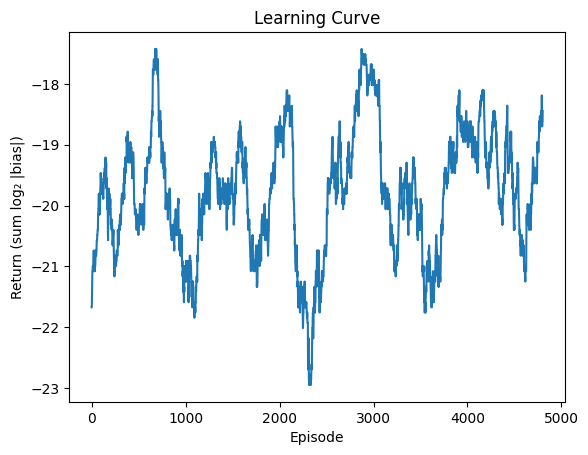

In [9]:
if 'returns' in globals() and returns:
    plt.figure()
    w = min(200, len(returns))
    ma = np.convolve(returns, np.ones(w)/w, mode='valid')
    plt.plot(ma)
    plt.title("Learning Curve")
    plt.xlabel("Episode"); plt.ylabel("Return (sum log₂ |bias|)")
    plt.show()
else:
    print("Nada que graficar aún.")


# Evaluate hulls

In [10]:
from dataclasses import dataclass
from typing import Callable, Any, List, Optional, Tuple

@dataclass
class StepLog:
    t: int
    state: Any               # (uH,uL,vH,vL,b,phase)
    action: Optional[int]    # w8
    reward: float
    next_state: Any
    done: bool
    info: dict               # cw_round, bias_round, w16, etc.
    q_values: Optional[List[Tuple[int, float]]] = None  # [(a, Q(s,a)), ...]

@dataclass
class PathLog:
    steps: List[StepLog]
    return_: float

# ------------------------------------------------------------
# Helpers de política/Q
# ------------------------------------------------------------
def actions_of(env: EnvHier8to16, s) -> List[int]:
    return list(env.actions(s))

def q_values_of(agent: QAgent, s, actions: List[int]) -> List[Tuple[int,float]]:
    qs = agent.Q[s]  # defaultdict(float)
    return [(a, qs[a]) for a in actions]

def argmax_q(qsa: List[Tuple[int,float]]) -> Optional[int]:
    return max(qsa, key=lambda x: (x[1], random.random()))[0] if qsa else None

# ------------------------------------------------------------
# Rollout GREEDY (ε=0)
# ------------------------------------------------------------
def rollout_greedy(env: EnvHier8to16, agent: QAgent, init_state, max_steps: int = 64) -> PathLog:
    s = env.reset(init_state=init_state)
    steps: List[StepLog] = []
    G = 0.0
    for t in range(max_steps):
        acts = actions_of(env, s)
        if not acts:
            steps.append(StepLog(t, s, None, 0.0, s, True, {"note":"no_actions"}, None))
            break
        qsa = q_values_of(agent, s, acts)
        a = argmax_q(qsa)  # sin exploración
        s_next, r, done, info = env.step(a)
        steps.append(StepLog(t, s, a, r, s_next, bool(done), info, qsa))
        G += r
        s = s_next
        if done:
            break
    return PathLog(steps=steps, return_=G)

# ------------------------------------------------------------
# N rollouts con ε fijo (no toca agent.epsilon global)
# ------------------------------------------------------------
def rollout_eps(env: EnvHier8to16, agent: QAgent, init_state, eps: float, n: int = 5, max_steps: int = 64) -> List[PathLog]:
    paths = []
    for _ in range(n):
        s = env.reset(init_state=init_state)
        steps: List[StepLog] = []
        G = 0.0
        for t in range(max_steps):
            acts = actions_of(env, s)
            if not acts:
                steps.append(StepLog(t, s, None, 0.0, s, True, {"note":"no_actions"}, None))
                break
            if random.random() < eps:
                a = random.choice(acts)
                qsa = q_values_of(agent, s, acts)
            else:
                qsa = q_values_of(agent, s, acts)
                a = argmax_q(qsa)
            s_next, r, done, info = env.step(a)
            steps.append(StepLog(t, s, a, r, s_next, bool(done), info, qsa))
            G += r
            s = s_next
            if done:
                break
        paths.append(PathLog(steps=steps, return_=G))
    return paths

# ------------------------------------------------------------
# Beam search (Top-K) guiado por Q
# ------------------------------------------------------------
def beam_search_paths(env_factory: Callable[[], EnvHier8to16],
                      agent: QAgent,
                      init_state,
                      K: int = 5,
                      depth: int = 8) -> List[PathLog]:
    """
    Mantiene un haz de K trayectorias; expansión ordenada por Q(s,a).
    Guarda y restaura 'partial' cuando el estado está en phase=1.
    Score = return real + (si no done) max_a' Q(s',a') como heurística.
    """

    # BeamItem: (score, PathLog, state, partial)
    # partial es None o una tupla (wH, cwH, bH) válida para phase=1
    def reset_with_state_and_partial(env: EnvHier8to16, s, partial):
        env.reset(init_state=s)
        # Si el estado está en phase=1 y tenemos partial, rehidrátalo
        if s[-1] == 1 and partial is not None:
            env.partial = partial
        return env

    # Inicialización
    env0 = env_factory()
    s0 = env0.reset(init_state=init_state)
    # Acciones iniciales (phase=0 esperado; si no, no pasa nada, sólo se usará lo que haya)
    acts0 = actions_of(env0, s0)
    q0 = q_values_of(agent, s0, acts0)
    h0 = max([q for _, q in q0], default=0.0)
    beam: List[Tuple[float, PathLog, Any, Optional[Tuple[int,int,int]]]] = [
        (h0, PathLog(steps=[], return_=0.0), s0, None)  # al inicio no hay partial
    ]

    for d in range(depth):
        new_beam = []
        for score, path, s, partial in beam:
            # Crea un env y rehidrata partial si corresponde
            env = reset_with_state_and_partial(env_factory(), s, partial)
            acts = actions_of(env, s)
            if not acts:
                # Sin acciones: conservar la hoja
                new_beam.append((path.return_, path, s, partial))
                continue

            qsa = q_values_of(agent, s, acts)
            # Expandir por acciones con mejor Q primero
            for a, q in sorted(qsa, key=lambda x: x[1], reverse=True):
                # Clonar por construcción de un env nuevo desde (s, partial)
                env2 = reset_with_state_and_partial(env_factory(), s, partial)
                s_next, r, done, info = env2.step(a)  # esto actualiza env2.partial si pasa a phase=1
                step = StepLog(d, s, a, r, s_next, bool(done), info, qsa)
                new_path = PathLog(path.steps + [step], path.return_ + r)

                # Heurística: max Q en s_next
                h = 0.0
                if not done:
                    acts_next = actions_of(env2, s_next)  # válido: env2 ya trae partial si s_next.phase==1
                    qnext = q_values_of(agent, s_next, acts_next)
                    h = max([qq for _, qq in qnext], default=0.0)

                # Transportar partial del env2 junto con el siguiente estado
                next_partial = getattr(env2, "partial", None)
                new_beam.append((new_path.return_ + h, new_path, s_next, next_partial))

        # Top-K por score
        new_beam.sort(key=lambda x: x[0], reverse=True)
        beam = new_beam[:K]

        # Cortar si todos ya terminaron
        if all(p.steps and p.steps[-1].done for _, p, _, _ in beam):
            break

    # Devolver sólo los caminos, ordenados por retorno real
    out = [p for _, p, _, _ in beam]
    out.sort(key=lambda p: p.return_, reverse=True)
    return out

## Helpers

In [11]:
def fmt_state(s):
    uH,uL,vH,vL,b,phase = s
    return f"(uH={uH:02X},uL={uL:02X},vH={vH:02X},vL={vL:02X},b={b},ph={phase})"

def fmt_action(a):
    return "∅" if a is None else f"w8={a:02X}"

def pretty_path(path: PathLog) -> str:
    lines = [f"Return = {path.return_:.6e}, steps = {len(path.steps)}"]
    G = 0.0
    for st in path.steps:
        G += st.reward
        info = st.info or {}
        cw   = info.get("cw_round", None)
        bias = info.get("bias_round", None)
        w16  = info.get("w16", None)
        extra = []
        if cw is not None:   extra.append(f"cw={cw}")
        if bias is not None: extra.append(f"bias={bias:.3e}")
        if w16 is not None:  extra.append(f"w16={w16:04X}")
        best_a = None; best_q = None
        if st.q_values:
            best_a, best_q = max(st.q_values, key=lambda x: x[1])
        best_str = f" | best={best_a:02X} Q={best_q:.3e}" if best_a is not None else ""
        lines.append(
            f"t={st.t:02d}  s={fmt_state(st.state)}  a={fmt_action(st.action)}  "
            f"r={st.reward:.3e}  -> s'={fmt_state(st.next_state)}  done={st.done}  "
            + (" ".join(extra) if extra else "") + best_str
        )
    lines.append(f"==> G = {G:.6e}")
    return "\n".join(lines)

def first_valid_hi_action(env: EnvHier8to16, s):
    """Devuelve el primer wH válido para phase=0 en el estado s (o None)."""
    uH,uL,vH,vL,b,phase = s
    assert phase == 0
    row = env._row_for(uH, vH) or {}
    for w, bd in row.items():
        if (bd is not None) and ((b in bd) or (str(b) in bd)):
            return int(w)
    return None

## Evaluate function

In [12]:
def evaluate(env: EnvHier8to16,
             agent: QAgent,
             init_state=None,
             n_eps_paths: int = 3,
             eps: float = 0.10,
             do_beam: bool = True,
             K: int = 5,
             depth: int = 8,
             ensure_valid: bool = True):
    """
    - Si init_state es None o no tiene acciones y ensure_valid=True, usa _sample_valid_state().
    - Imprime GREEDY + N rollouts con ε + Top-K (opcional).
    """
    if init_state is None:
        s0 = env._sample_valid_state() if ensure_valid else env.reset()
    else:
        s0 = init_state

    if not env.actions(s0) and ensure_valid:
        s0 = env._sample_valid_state()

    print("Estado inicial:", fmt_state(s0))
    print("Acciones disponibles en s0:", env.actions(s0))

    greedy = rollout_greedy(env, agent, init_state=s0, max_steps=2*env.R)
    print("\n=== GREEDY ===")
    print(pretty_path(greedy))

    eps_paths = rollout_eps(env, agent, init_state=s0, eps=eps, n=n_eps_paths, max_steps=2*env.R)
    for i, p in enumerate(eps_paths, 1):
        print(f"\n=== EPS PATH #{i} (eps={eps}) ===")
        print(pretty_path(p))

    if do_beam:
        def make_env():
            # Debe devolver un env fresco del mismo tipo:
            return EnvHier8to16(env.P, env.S, rounds=env.R, reward_mode=env.reward_mode, carry=env.carry)
        topk = beam_search_paths(make_env, agent, init_state=s0, K=K, depth=depth)
        for i, p in enumerate(topk, 1):
            print(f"\n=== TOP-{i} (return={p.return_:.6e}) ===")
            print(pretty_path(p))

## Evaluate

In [13]:
# =========================================
#  A) Evaluar desde un estado específico
# =========================================
s0 = (0x12, 0x34, 0xAB, 0xCD, 0, 0)  # phase=0 -> elige wH primero

# Imprime: GREEDY, 3 rollouts con ε=0.10, y Top-K (K=5, depth=8)
evaluate(
    env,
    agent,
    init_state=s0,
    n_eps_paths=3,
    eps=0.10,
    do_beam=True,
    K=5,
    depth=8,
    ensure_valid=True  # si s0 no tiene acciones, toma uno válido similar automáticamente
)


Estado inicial: (uH=78,uL=BB,vH=4F,vL=FA,b=0,ph=0)
Acciones disponibles en s0: [110, 111, 118, 119]

=== GREEDY ===
Return = -1.700000e+01, steps = 2
t=00  s=(uH=78,uL=BB,vH=4F,vL=FA,b=0,ph=0)  a=w8=6E  r=0.000e+00  -> s'=(uH=78,uL=BB,vH=4F,vL=FA,b=0,ph=1)  done=False   | best=6E Q=0.000e+00
t=01  s=(uH=78,uL=BB,vH=4F,vL=FA,b=0,ph=1)  a=w8=F0  r=-1.700e+01  -> s'=(uH=E0,uL=DD,vH=51,vL=19,b=0,ph=0)  done=True  cw=16 bias=7.629e-06 w16=6EF0 | best=A0 Q=0.000e+00
==> G = -1.700000e+01

=== EPS PATH #1 (eps=0.1) ===
Return = -1.700000e+01, steps = 2
t=00  s=(uH=78,uL=BB,vH=4F,vL=FA,b=0,ph=0)  a=w8=6E  r=0.000e+00  -> s'=(uH=78,uL=BB,vH=4F,vL=FA,b=0,ph=1)  done=False   | best=6E Q=0.000e+00
t=01  s=(uH=78,uL=BB,vH=4F,vL=FA,b=0,ph=1)  a=w8=FB  r=-1.700e+01  -> s'=(uH=F6,uL=DD,vH=51,vL=12,b=0,ph=0)  done=True  cw=16 bias=7.629e-06 w16=6EFB | best=A0 Q=0.000e+00
==> G = -1.700000e+01

=== EPS PATH #2 (eps=0.1) ===
Return = -3.400000e+01, steps = 4
t=00  s=(uH=78,uL=BB,vH=4F,vL=FA,b=0,ph=0)  a=

In [14]:
# =========================================
#  A) Evaluar desde un estado específico
# =========================================
s0 = (0x00, 0x06, 0x00, 0x00, 0, 0)  # phase=0 -> elige wH primero

# Imprime: GREEDY, 3 rollouts con ε=0.10, y Top-K (K=5, depth=8)
evaluate(
    env,
    agent,
    init_state=s0,
    n_eps_paths=3,
    eps=0.10,
    do_beam=True,
    K=5,
    depth=8,
    ensure_valid=True  # si s0 no tiene acciones, toma uno válido similar automáticamente
)


Estado inicial: (uH=00,uL=06,vH=00,vL=00,b=0,ph=0)
Acciones disponibles en s0: [0]

=== GREEDY ===
Return = 0.000000e+00, steps = 2
t=00  s=(uH=00,uL=06,vH=00,vL=00,b=0,ph=0)  a=w8=00  r=0.000e+00  -> s'=(uH=00,uL=06,vH=00,vL=00,b=0,ph=1)  done=False   | best=00 Q=0.000e+00
t=01  s=(uH=00,uL=06,vH=00,vL=00,b=0,ph=1)  a=∅  r=0.000e+00  -> s'=(uH=00,uL=06,vH=00,vL=00,b=0,ph=1)  done=True  
==> G = 0.000000e+00

=== EPS PATH #1 (eps=0.1) ===
Return = 0.000000e+00, steps = 2
t=00  s=(uH=00,uL=06,vH=00,vL=00,b=0,ph=0)  a=w8=00  r=0.000e+00  -> s'=(uH=00,uL=06,vH=00,vL=00,b=0,ph=1)  done=False   | best=00 Q=0.000e+00
t=01  s=(uH=00,uL=06,vH=00,vL=00,b=0,ph=1)  a=∅  r=0.000e+00  -> s'=(uH=00,uL=06,vH=00,vL=00,b=0,ph=1)  done=True  
==> G = 0.000000e+00

=== EPS PATH #2 (eps=0.1) ===
Return = 0.000000e+00, steps = 2
t=00  s=(uH=00,uL=06,vH=00,vL=00,b=0,ph=0)  a=w8=00  r=0.000e+00  -> s'=(uH=00,uL=06,vH=00,vL=00,b=0,ph=1)  done=False   | best=00 Q=0.000e+00
t=01  s=(uH=00,uL=06,vH=00,vL=00,b=0,

# Multiple Masks Experiment

## Helpers

In [15]:
from typing import List, Tuple, Union
import numpy as np

def load_masks(
    path: str,
    as_numpy: bool = True,
    dtype = np.uint16,
) -> Union[np.ndarray, List[int], List[Tuple[int, int]]]:
    """
    Carga máscaras desde un archivo de texto.

    Formatos soportados (por línea):
        0xAAAA
        0xAAAA    0xBBBB      (separado por espacio o tab)

    Parámetros
    ----------
    path : str
        Ruta al archivo .txt.
    as_numpy : bool, por defecto True
        - True  → devuelve np.ndarray
                 * 1 columna  → shape (n,)
                 * 2 columnas → shape (n, 2)
        - False → lista de enteros o lista de tuplas (x, y).
    dtype : tipo numpy, por defecto np.uint16
        Tipo de los enteros en el array.

    Returns
    -------
    np.ndarray o lista
    """
    xs: List[int] = []
    ys: List[int] = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue  # saltar líneas vacías

            parts = line.split()
            if len(parts) == 1:
                # Solo una máscara por línea
                x = int(parts[0], 0)   # base automática (0x..., decimal, etc.)
                xs.append(x)
            elif len(parts) >= 2:
                # Tomamos solo las dos primeras columnas
                x = int(parts[0], 0)
                y = int(parts[1], 0)
                xs.append(x)
                ys.append(y)

    if as_numpy:
        if ys:  # hay segunda columna → pares
            arr_x = np.array(xs, dtype=dtype)
            arr_y = np.array(ys, dtype=dtype)
            return np.stack([arr_x, arr_y], axis=1)   # shape (n, 2)
        else:
            return np.array(xs, dtype=dtype)          # shape (n,)
    else:
        if ys:
            return list(zip(xs, ys))                  # [(x0, y0), ...]
        else:
            return xs                                 # [x0, x1, ...]


In [16]:
def masks_to_state(u16: int, v16: int, b: int = 0, phase: int = 0):
    """
    Convierte dos máscaras de 16 bits (u, v) en un estado (uH, uL, vH, vL, b, phase).
    """
    u16 &= 0xFFFF
    v16 &= 0xFFFF
    uH, uL = (u16 >> 8) & 0xFF, u16 & 0xFF
    vH, vL = (v16 >> 8) & 0xFF, v16 & 0xFF
    return (uH, uL, vH, vL, b, phase)


In [17]:
from math import inf

def max_return_for_masks(
    env: EnvHier8to16,
    agent: QAgent,
    u16: int,
    v16: int,
    n_eps_paths: int = 3,
    eps: float = 0.10,
    do_beam: bool = True,
    K: int = 5,
    depth: int = 8,
):
    """
    Devuelve el máximo retorno que alcanza el agente partiendo del estado
    definido por las máscaras (u16, v16).
    """
    # 1) estado inicial fijado por las máscaras
    s0 = masks_to_state(u16, v16, b=0, phase=0)

    # Si no hay acciones desde s0, devolvemos -inf (o None si prefieres)
    if not env.actions(s0):
        return float("-inf")

    # 2) rollout GREEDY
    greedy = rollout_greedy(env, agent, init_state=s0, max_steps=2 * env.R)
    best_return = greedy.return_

    # 3) rollouts con ε-greedy
    eps_paths = rollout_eps(
        env,
        agent,
        init_state=s0,
        eps=eps,
        n=n_eps_paths,
        max_steps=2 * env.R,
    )
    for p in eps_paths:
        if p.return_ > best_return:
            best_return = p.return_

    # 4) beam search: top-K caminos
    if do_beam:
        def make_env():
            return EnvHier8to16(
                env.P,
                env.S,
                rounds=env.R,
                reward_mode=env.reward_mode,
                carry=env.carry,
            )

        topk = beam_search_paths(
            make_env,
            agent,
            init_state=s0,
            K=K,
            depth=depth,
        )
        if topk:
            # beam_search_paths normalmente devuelve ya ordenado por retorno
            if topk[0].return_ > best_return:
                best_return = topk[0].return_

    return best_return

In [18]:
def retornos_pares(pares_list):
  retornos = []
  for par in pares_list:
      x = par[0] #Mascara izquierda
      y = par[1] #Mascara derecha
      retorno = max_return_for_masks(env, agent, x, y)
      retornos.append(retorno)
  return retornos



In [19]:
from math import inf

# 1) partir las máscaras de 16 bits en (uH, uL, vH, vL)
def split_uv(u16: int, v16: int, word_size: int = 16):
    """
    Convierte dos máscaras de 16 bits (u16, v16) en uH, uL, vH, vL (8 bits cada uno).
    Asumo Speck16 → word_size = 16 → 8 bits altos + 8 bits bajos.
    """
    mask = (1 << word_size) - 1      # 0xFFFF
    half = word_size // 2            # 8

    u16 &= mask
    v16 &= mask

    uH, uL = (u16 >> half) & ((1 << half) - 1), u16 & ((1 << half) - 1)
    vH, vL = (v16 >> half) & ((1 << half) - 1), v16 & ((1 << half) - 1)
    return uH, uL, vH, vL


# 2) buscar en env.S todos los estados cuyo (uH,uL,vH,vL) coincide
def estados_para_par(env, u16: int, v16: int, phase: int = 0):
    """
    Devuelve todos los estados s en env.S tales que:
        (uH,uL,vH,vL, b, phase_s) cumplen
        uH,uL,vH,vL = split_uv(u16, v16) y phase_s == phase.

    Asumo que un estado es una tupla:
        (uH, uL, vH, vL, b, phase)
    y que env.S es o bien:
        - un set/list de estados, o
        - un dict cuyo .keys() son los estados.
    """
    uH, uL, vH, vL = split_uv(u16, v16)

    S = env.S
    # si es dict, iteramos sobre las llaves; si no, sobre S directamente
    iterable = S.keys() if hasattr(S, "keys") else S

    candidatos = []
    for state in iterable:
        suH, suL, svH, svL, b, ph = state
        if suH == uH and suL == uL and svH == vH and svL == vL and ph == phase:
            candidatos.append(s)

    return candidatos

## Experimento

In [20]:
pares_list = load_masks("pares_1234_abcd.txt", as_numpy=False)
print(pares_list[:5])   # [(x0, y0), (x1, y1), ...]

[(59609, 1053), (52778, 9745), (9397, 2744), (20654, 64609), (15017, 17805)]


In [21]:
calculated_retornos = retornos_pares(pares_list)

In [22]:
ret = np.array(calculated_retornos)
mask = np.isfinite(ret)
min_finite = ret[mask].min()

#A las parejas que no tienen estados validos, se les asigna un valor inferior al mínimo para gráficar
floor_val = min_finite - 5
ret_floor = np.where(mask, ret, floor_val)

## Gráfica

In [23]:
len(pares_list)

1000

In [24]:
len(calculated_retornos)

1000

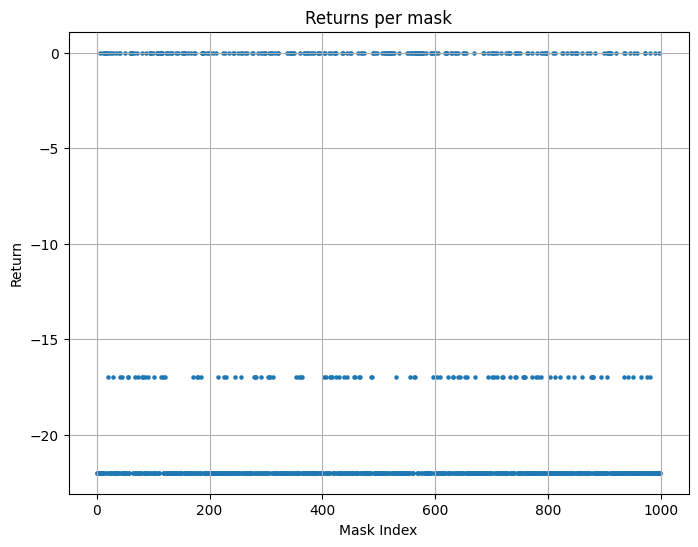

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(range(len(pares_list)), ret_floor, s=5)   # s: tamaño del punto
plt.xlabel('Mask Index')
plt.ylabel('Return')
plt.title('Returns per mask')
plt.grid(True)
plt.show()

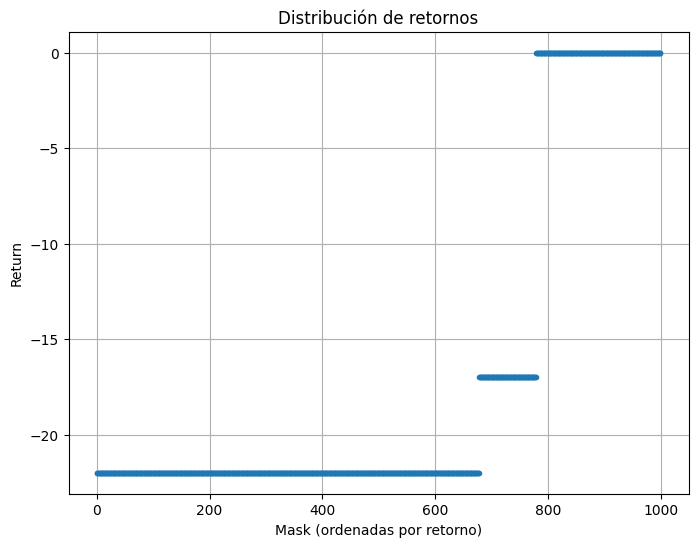

In [26]:
sorted_ret = np.sort(ret_floor)

plt.figure(figsize=(8,6))
plt.plot(sorted_ret, marker='.', linestyle='none')
plt.xlabel('Mask (ordenadas por retorno)')
plt.ylabel('Return')
plt.title('Distribución de retornos')
plt.grid(True)
plt.show()


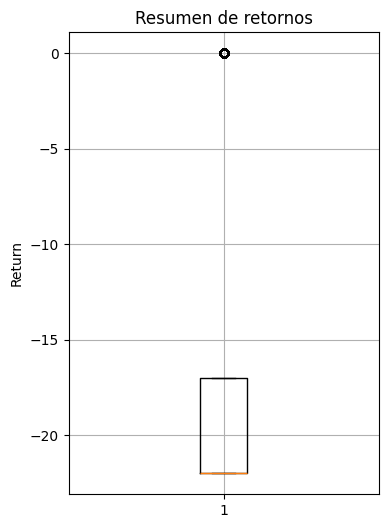

In [27]:
plt.figure(figsize=(4,6))
plt.boxplot(ret_floor, vert=True)
plt.ylabel('Return')
plt.title('Resumen de retornos')
plt.grid(True)
plt.show()


### Pie chart para la distribución del piling up lemma

In [28]:
number_zeros =  (ret_floor == 0).sum()
print(number_zeros)

221


In [29]:
value = -39
number_non_valid =  (ret_floor == value).sum()
print(number_non_valid)

0


In [30]:
value = -34
number_thirty_four =  (ret_floor == value).sum()
print(number_thirty_four)

0


In [31]:
value = -17
number_seventeen =  (ret_floor == value).sum()
print(number_seventeen)

101


In [32]:
num_total = len(ret_floor)
print(num_total)

1000


In [33]:
percentages = []
percentage_non_valid = (number_non_valid / num_total) * 100
percentages.append(percentage_non_valid)
percentage_zeros = (number_zeros / num_total) * 100
percentages.append(percentage_zeros)
percentage_thirty_four = (number_thirty_four / num_total) * 100
percentages.append(percentage_thirty_four)
percentage_seventeen = (number_seventeen / num_total) * 100
percentages.append(percentage_seventeen)

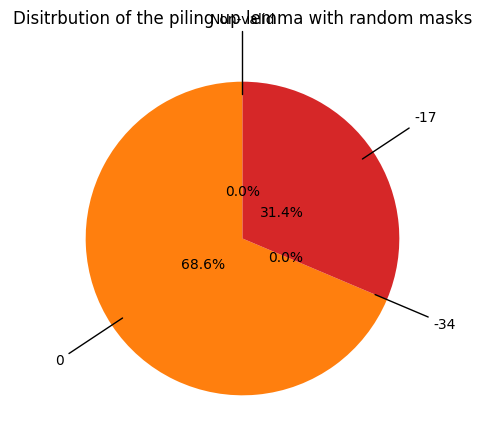

In [34]:
import matplotlib.pyplot as plt
import numpy as np

sizes  = percentages
labels = ['Non-valid', '0', '-34', '-17']

fig, ax = plt.subplots(figsize=(6, 5))

wedges, texts, autotexts = ax.pie(
    sizes,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.3
)

for i, w in enumerate(wedges):
    ang = 0.5 * (w.theta1 + w.theta2)
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))

    xy = (0.9 * x, 0.9 * y)
    xytext = (1.4 * x, 1.4 * y)

    ax.annotate(
        labels[i],
        xy=xy,
        xytext=xytext,
        arrowprops=dict(arrowstyle='-', linewidth=1),
        ha='center',
        va='center'
    )

plt.subplots_adjust(top=0.8)

plt.title('Disitrbution of the piling up lemma with random masks', y=1.10)
ax.axis('equal')
plt.show()


## Experimento con 0x0006 y 0x0000

In [35]:
pares_list = load_masks("pares_0006_0000.txt", as_numpy=False)
print(pares_list[:5])   # [(x0, y0), (x1, y1), ...]

[(1591, 18376), (12373, 61130), (34355, 25397), (23177, 5139), (13520, 16148)]


In [36]:
calculated_retornos = retornos_pares(pares_list)

In [37]:
ret = np.array(calculated_retornos)
mask = np.isfinite(ret)
min_finite = ret[mask].min()

#A las parejas que no tienen estados validos, se les asigna un valor inferior al mínimo para gráficar
floor_val = min_finite - 5
ret_floor = np.where(mask, ret, floor_val)

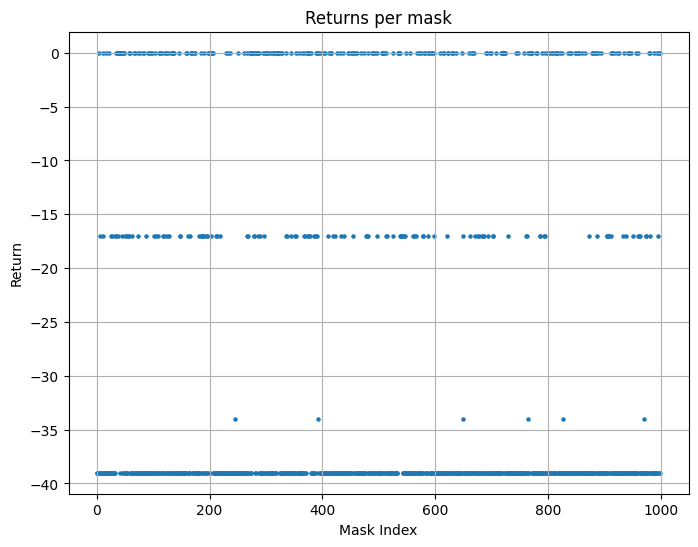

In [38]:
plt.figure(figsize=(8,6))
plt.scatter(range(len(pares_list)), ret_floor, s=5)   # s: tamaño del punto
plt.xlabel('Mask Index')
plt.ylabel('Return')
plt.title('Returns per mask')
plt.grid(True)
plt.show()

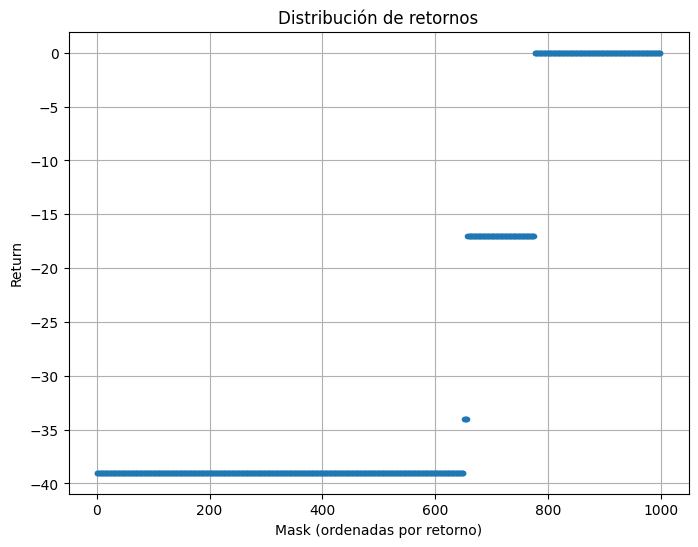

In [39]:
sorted_ret = np.sort(ret_floor)

plt.figure(figsize=(8,6))
plt.plot(sorted_ret, marker='.', linestyle='none')
plt.xlabel('Mask (ordenadas por retorno)')
plt.ylabel('Return')
plt.title('Distribución de retornos')
plt.grid(True)
plt.show()


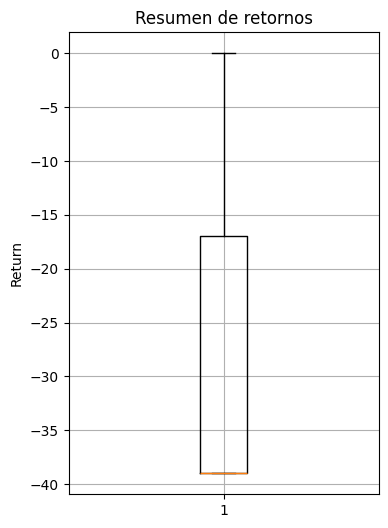

In [40]:
plt.figure(figsize=(4,6))
plt.boxplot(ret_floor, vert=True)
plt.ylabel('Return')
plt.title('Resumen de retornos')
plt.grid(True)
plt.show()


### Pie chart para la distribución del piling up lemma

In [41]:
number_zeros =  (ret_floor == 0).sum()
print(number_zeros)

224


In [42]:
value = -39
number_non_valid =  (ret_floor == value).sum()
print(number_non_valid)

651


In [43]:
value = -34
number_thirty_four =  (ret_floor == value).sum()
print(number_thirty_four)

6


In [44]:
value = -17
number_seventeen =  (ret_floor == value).sum()
print(number_seventeen)

119


In [45]:
num_total = len(ret_floor)
print(num_total)

1000


In [46]:
percentages = []
percentage_non_valid = (number_non_valid / num_total) * 100
percentages.append(percentage_non_valid)
percentage_zeros = (number_zeros / num_total) * 100
percentages.append(percentage_zeros)
percentage_thirty_four = (number_thirty_four / num_total) * 100
percentages.append(percentage_thirty_four)
percentage_seventeen = (number_seventeen / num_total) * 100
percentages.append(percentage_seventeen)

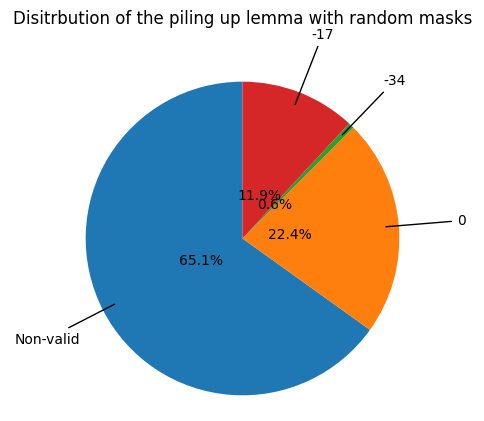

In [47]:
import matplotlib.pyplot as plt
import numpy as np

sizes  = percentages
labels = ['Non-valid', '0', '-34', '-17']

fig, ax = plt.subplots(figsize=(6, 5))

wedges, texts, autotexts = ax.pie(
    sizes,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.3
)

for i, w in enumerate(wedges):
    ang = 0.5 * (w.theta1 + w.theta2)
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))

    xy = (0.9 * x, 0.9 * y)
    xytext = (1.4 * x, 1.4 * y)

    ax.annotate(
        labels[i],
        xy=xy,
        xytext=xytext,
        arrowprops=dict(arrowstyle='-', linewidth=1),
        ha='center',
        va='center'
    )

plt.subplots_adjust(top=0.8)

plt.title('Disitrbution of the piling up lemma with random masks', y=1.10)
ax.axis('equal')
plt.show()


### Comparación con el algoritmo Matsui 3: Branch and Bound

#### Importar los caminos calculados con el algoritmo de matsui

In [48]:
df_matsui = pd.read_csv("matsui_from_1234_clat_pruned.csv")

# Asegurarnos de que alpha/beta sean enteros (no floats)
for col in ["alpha0", "beta0", "alphaR", "betaR",
            "seed_alpha0_dec", "seed_beta0_dec"]:
    # Fill NaN values with 0 before converting to int
    df_matsui[col] = df_matsui[col].fillna(300).astype(int)

df_matsui.head()

,seed_idx,seed_alpha0_dec,seed_beta0_dec,seed_alpha0_hex,seed_beta0_hex,alpha0,beta0,alphaR,betaR,alpha0_hex,beta0_hex,alphaR_hex,betaR_hex,cw_total
0,768,59712,72,0xe940,0x48,59712,72,96,64,0xe940,0x48,0x60,0x40,7.0
1,496,38979,121,0x9843,0x79,38979,121,97,65,0x9843,0x79,0x61,0x41,7.0
2,963,42613,155,0xa675,0x9b,42613,155,25,17,0xa675,0x9b,0x19,0x11,8.0
3,544,7463,236,0x1d27,0xec,7463,236,12,8,0x1d27,0xec,0xc,0x8,8.0
4,138,32798,165,0x801e,0xa5,32798,165,7,5,0x801e,0xa5,0x7,0x5,8.0


#### Helpers para el producto escalar y para resolver las aproximaciones

In [49]:
import math
import random

def scalar_prod(mask: int, word: int) -> int:
    """
    <mask, word> en GF(2) = paridad de (mask & word).
    Usa Speck.parity
    """
    return Speck.parity(mask & word)

def lin_form_plain_cipher(alpha0, beta0, alphaR, betaR, P, C):
    """
    Evalúa:
        <(alpha0, beta0), P> xor <(alphaR, betaR), C>
    donde P = (x0, y0), C = (xR, yR).

    Devuelve 0 si la ecuación lineal se cumple, 1 si no.
    """
    x0, y0 = P
    xR, yR = C

    in_part  = scalar_prod(alpha0, x0) ^ scalar_prod(beta0, y0)
    out_part = scalar_prod(alphaR, xR) ^ scalar_prod(betaR, yR)

    return in_part ^ out_part

def state_to_masks(state, word_size=16):
    uH, uL, vH, vL, b, phase = state
    half = word_size // 2
    mask8 = (1 << half) - 1

    u16 = ((uH & mask8) << half) | (uL & mask8)
    v16 = ((vH & mask8) << half) | (vL & mask8)
    return u16, v16

def best_path_for_masks(env: EnvHier8to16,
                        agent: QAgent,
                        u16: int,
                        v16: int,
                        K: int = 5,
                        depth: int = 8):
    s0 = masks_to_state(u16, v16, b=0, phase=0)

    if not env.actions(s0):
        return None

    greedy = rollout_greedy(env, agent, init_state=s0, max_steps=2 * env.R)
    best_path = greedy

    def make_env():
        return EnvHier8to16(env.P, env.S, rounds=env.R,
                            reward_mode=env.reward_mode, carry=env.carry)

    topk = beam_search_paths(make_env, agent, init_state=s0, K=K, depth=depth)
    if topk and topk[0].return_ > best_path.return_:
        best_path = topk[0]

    return best_path

### Estimador del sesgo

In [50]:
def estimate_bias_for_approx(
    speck: Speck,
    rounds: int,      # nº de rondas de la aproximación
    alpha0: int,
    beta0: int,
    alphaR: int,
    betaR: int,
    N: int = 1 << 16,  # nº de pares
):
    """
    Ataque experimental tipo Matsui:
      - fija una clave aleatoria
      - genera N pares (P,C) con 'rounds' rondas
      - estima el sesgo de la ecuación lineal
    """
    # 1) Clave aleatoria
    key = [random.randrange(1 << speck.word_size) for _ in range(speck.n_main_key_words)]
    speck.key_schedule(key)

    n = speck.word_size
    count_zero = 0

    for _ in range(N):
        # Texto claro aleatorio
        P = (random.randrange(1 << n), random.randrange(1 << n))
        # Cifrado con 'rounds' rondas
        C = speck.encrypt(P, rounds=rounds)

        if lin_form_plain_cipher(alpha0, beta0, alphaR, betaR, P, C) == 0:
            count_zero += 1

    p   = count_zero / N
    eps = p - 0.5
    return eps, p


### Ataque

In [51]:
rows_attack_ml = []

R = env.R
N_PAIRS = 1 << 16

df_seeds = df_matsui[["seed_idx", "seed_alpha0_dec", "seed_beta0_dec"]].drop_duplicates()
print("Nº de semillas únicas en df_matsui:", len(df_seeds))

n_no_actions = 0
n_no_steps   = 0

for _, row in df_seeds.iterrows():
    seed_idx = int(row["seed_idx"])
    u16_seed = int(row["seed_alpha0_dec"])
    v16_seed = int(row["seed_beta0_dec"])

    path = best_path_for_masks(env, agent, u16_seed, v16_seed, K=5, depth=8)

    if path is None:
        n_no_actions += 1
        # opcional: registrar igual la semilla
        rows_attack_ml.append({
            "method": "ml",
            "seed_idx": seed_idx,
            "seed_alpha0_hex": hex(u16_seed),
            "seed_beta0_hex":  hex(v16_seed),
            "alpha0_hex": None,
            "beta0_hex":  None,
            "alphaR_hex": None,
            "betaR_hex":  None,
            "cw_total_teorico_ml": 100.0,
            "return_ml": 0.0,
            "p_emp": None,
            "eps_emp": None,
            "cw_emp": 100.0,
        })
        continue

    if not path.steps:
        n_no_steps += 1
        # igual lo guardas con valores neutros
        rows_attack_ml.append({
            "method": "ml",
            "seed_idx": seed_idx,
            "seed_alpha0_hex": hex(u16_seed),
            "seed_beta0_hex":  hex(v16_seed),
            "alpha0_hex": None,
            "beta0_hex":  None,
            "alphaR_hex": None,
            "betaR_hex":  None,
            "cw_total_teorico_ml": 100.0,
            "return_ml": path.return_,
            "p_emp": None,
            "eps_emp": None,
            "cw_emp": 100.0,
        })
        continue

    # ---- caso normal: sí hubo camino ----
    s_start = path.steps[0].state
    s_end   = path.steps[-1].next_state

    alpha0_ml, beta0_ml = state_to_masks(s_start, word_size=speck.word_size)
    alphaR_ml, betaR_ml = state_to_masks(s_end,   word_size=speck.word_size)

    cw_total_ml = sum(
        step.info.get("cw_round", 0.0)
        for step in path.steps
        if isinstance(step.info, dict) and "cw_round" in step.info
    )

    eps_exp, p_exp = estimate_bias_for_approx(
        speck=speck,
        rounds=R,
        alpha0=alpha0_ml,
        beta0=beta0_ml,
        alphaR=alphaR_ml,
        betaR=betaR_ml,
        N=N_PAIRS,
    )

    cw_emp = -math.log2(abs(eps_exp)) if eps_exp != 0 else float("inf")

    rows_attack_ml.append({
        "method": "ml",
        "seed_idx": seed_idx,
        "seed_alpha0_hex": hex(u16_seed),
        "seed_beta0_hex":  hex(v16_seed),
        "alpha0_hex": hex(alpha0_ml),
        "beta0_hex":  hex(beta0_ml),
        "alphaR_hex": hex(alphaR_ml),
        "betaR_hex":  hex(betaR_ml),
        "cw_total_teorico_ml": cw_total_ml,
        "return_ml": path.return_,
        "p_emp": p_exp,
        "eps_emp": eps_exp,
        "cw_emp": cw_emp,
    })

df_attack_ml = pd.DataFrame(rows_attack_ml)
print("Semillas totales:", len(df_seeds))
print("Sin acciones:", n_no_actions, " / sin pasos:", n_no_steps)
print("Filas en df_attack_ml:", len(df_attack_ml))

Nº de semillas únicas en df_matsui: 1000
Semillas totales: 1000
Sin acciones: 678  / sin pasos: 0
Filas en df_attack_ml: 1000


In [52]:
df_attack_ml["cw_total_teorico_ml"] = (
    df_attack_ml["cw_total_teorico_ml"]
    .replace([np.inf, -np.inf], 100.0)
)

In [53]:
df_attack_ml["cw_total_teorico_ml"].unique()

array([100.,   0.,  16.,  32.])

### Gráfica de resultados

In [54]:
df_matsui["cw_total"] = (
    df_matsui["cw_total"]
    .replace([np.inf, -np.inf], 100.0)
)

Total semillas comparadas : 1000
Matsui mejor      : 6 (0.60%)
RL mejor          : 101 (10.10%)
Empate (válido)   : 0 (0.00%)
Non-valid (0/100) : 893 (89.30%)


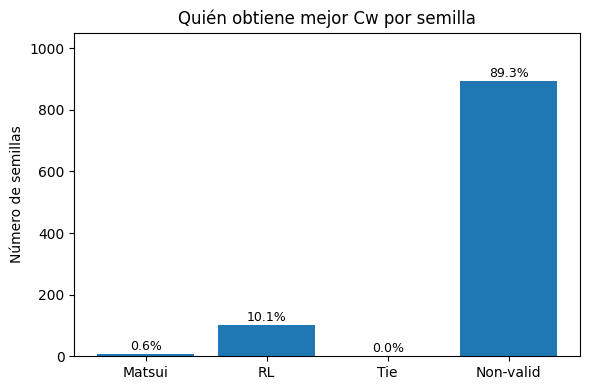

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Mejor Cw de cada método por par de máscaras
best_matsui = (
    df_matsui
    .groupby(["seed_alpha0_hex", "seed_beta0_hex"])["cw_total"]
    .min()
    .reset_index()
    .rename(columns={"cw_total": "cw_matsui"})
)

best_rl = (
    df_attack_ml
    .groupby(["seed_alpha0_hex", "seed_beta0_hex"])["cw_total_teorico_ml"]
    .min()
    .reset_index()
    .rename(columns={"cw_total_teorico_ml": "cw_rl"})
)

# 2) Emparejar por máscaras iniciales
df_comp = best_matsui.merge(
    best_rl,
    on=["seed_alpha0_hex", "seed_beta0_hex"],
    how="inner",
)

# 3) Determinar ganador
cw_m = df_comp["cw_matsui"].to_numpy()
cw_r = df_comp["cw_rl"].to_numpy()

winner = np.full(len(df_comp), "Non-valid", dtype=object)  # por defecto

# Valores no válidos: 0 ó 100
m_invalid = (cw_m == 0) | (cw_m == 100)
r_invalid = (cw_r == 0) | (cw_r == 100)

# Ambos no válidos -> Non-valid (ya está por defecto)
both_invalid = m_invalid & r_invalid

# Resto: al menos uno válido
mask_rest = ~both_invalid

# Para comparar, tratamos los no válidos como un número enorme
BIG = 10**9
m_eff = np.where(mask_rest & m_invalid, BIG, cw_m)
r_eff = np.where(mask_rest & r_invalid, BIG, cw_r)

# Gana el válido más pequeño
winner[mask_rest & (r_eff < m_eff)] = "RL"
winner[mask_rest & (m_eff < r_eff)] = "Matsui"

# Empate real: ambos válidos e iguales
mask_tie_real = (
    mask_rest &
    ~m_invalid & ~r_invalid &
    (cw_m == cw_r)
)
winner[mask_tie_real] = "Tie"

df_comp["winner"] = winner

# 4) Estadísticas y porcentajes
counts = df_comp["winner"].value_counts()
total  = len(df_comp)

n_matsui   = counts.get("Matsui", 0)
n_rl       = counts.get("RL", 0)
n_tie      = counts.get("Tie", 0)
n_nonvalid = counts.get("Non-valid", 0)

pct_matsui   = 100 * n_matsui / total
pct_rl       = 100 * n_rl / total
pct_tie      = 100 * n_tie / total
pct_nonvalid = 100 * n_nonvalid / total

print(f"Total semillas comparadas : {total}")
print(f"Matsui mejor      : {n_matsui} ({pct_matsui:.2f}%)")
print(f"RL mejor          : {n_rl} ({pct_rl:.2f}%)")
print(f"Empate (válido)   : {n_tie} ({pct_tie:.2f}%)")
print(f"Non-valid (0/100) : {n_nonvalid} ({pct_nonvalid:.2f}%)")

# 5) Gráfico de barras
labels = ["Matsui", "RL", "Tie", "Non-valid"]
values = [n_matsui, n_rl, n_tie, n_nonvalid]
pcts   = [pct_matsui, pct_rl, pct_tie, pct_nonvalid]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, values)

for bar, pct in zip(bars, pcts):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f"{pct:.1f}%",
        ha="center", va="bottom", fontsize=9
    )

plt.ylabel("Número de semillas")
plt.title("Quién obtiene mejor Cw por semilla")
plt.ylim(0, total * 1.05)
plt.tight_layout()
plt.show()


In [56]:
cuentas = df_comp['cw_matsui'] > df_comp['cw_rl']

In [57]:
cuentas.value_counts(True)

,proportion
False,0.678
True,0.322


In [58]:
matsui_win = df_comp[df_comp["winner"] == "Matsui"]
matsui_win


,seed_alpha0_hex,seed_beta0_hex,cw_matsui,cw_rl,winner
66,0x1d27,0xec,8.0,100.0,Matsui
203,0x3d0f,0xce,8.0,100.0,Matsui
477,0x801e,0xa5,8.0,100.0,Matsui
571,0x9843,0x79,7.0,100.0,Matsui
638,0xa675,0x9b,8.0,100.0,Matsui
920,0xe940,0x48,7.0,100.0,Matsui


In [59]:
matsui_win = df_comp[df_comp["winner"] == "RL"]
matsui_win

,seed_alpha0_hex,seed_beta0_hex,cw_matsui,cw_rl,winner
49,0x1a47,0x1c4e,100.0,16.0,RL
100,0x22c8,0x3e9a,100.0,16.0,RL
171,0x34ef,0x2fde,100.0,16.0,RL
190,0x3a8a,0x2dbb,100.0,16.0,RL
207,0x3dfa,0x3eff,100.0,16.0,RL
...,...,...,...,...,...
985,0xfb8f,0xadec,100.0,16.0,RL
986,0xfba1,0xdae6,100.0,16.0,RL
987,0xfbc3,0xcbe3,100.0,16.0,RL
996,0xfea7,0xfd91,100.0,16.0,RL


### Máscara x = 0x0006 y y = 0x0000

In [60]:
df_matsui = pd.read_csv("matsui_from_0006_clat_pruned.csv")

# Asegurarnos de que alpha/beta sean enteros (no floats)
for col in ["alpha0", "beta0", "alphaR", "betaR",
            "seed_alpha0_dec", "seed_beta0_dec"]:
    # Fill NaN values with 0 before converting to int
    df_matsui[col] = df_matsui[col].fillna(300).astype(int)

df_matsui.head()

,seed_idx,seed_alpha0_dec,seed_beta0_dec,seed_alpha0_hex,seed_beta0_hex,alpha0,beta0,alphaR,betaR,alpha0_hex,beta0_hex,alphaR_hex,betaR_hex,cw_total
0,451,28282,121,0x6e7a,0x79,28282,121,97,65,0x6e7a,0x79,0x61,0x41,7.0
1,836,65138,93,0xfe72,0x5d,65138,93,97,65,0xfe72,0x5d,0x61,0x41,8.0
2,627,6034,102,0x1792,0x66,6034,102,6,4,0x1792,0x66,0x6,0x4,8.0
3,847,31087,237,0x796f,0xed,31087,237,13,9,0x796f,0xed,0xd,0x9,8.0
4,32,60200,180,0xeb28,0xb4,60200,180,48,32,0xeb28,0xb4,0x30,0x20,8.0


In [61]:
df_matsui["cw_total"].unique()

array([ 7.,  8.,  9., inf])

### Ataque

In [62]:
rows_attack_ml = []

R = env.R
N_PAIRS = 1 << 16

df_seeds = df_matsui[["seed_idx", "seed_alpha0_dec", "seed_beta0_dec"]].drop_duplicates()
print("Nº de semillas únicas en df_matsui:", len(df_seeds))

n_no_actions = 0
n_no_steps   = 0

for _, row in df_seeds.iterrows():
    seed_idx = int(row["seed_idx"])
    u16_seed = int(row["seed_alpha0_dec"])
    v16_seed = int(row["seed_beta0_dec"])

    path = best_path_for_masks(env, agent, u16_seed, v16_seed, K=5, depth=8)

    if path is None:
        n_no_actions += 1
        # opcional: registrar igual la semilla
        rows_attack_ml.append({
            "method": "ml",
            "seed_idx": seed_idx,
            "seed_alpha0_hex": hex(u16_seed),
            "seed_beta0_hex":  hex(v16_seed),
            "alpha0_hex": None,
            "beta0_hex":  None,
            "alphaR_hex": None,
            "betaR_hex":  None,
            "cw_total_teorico_ml": 100.0,
            "return_ml": 0.0,
            "p_emp": None,
            "eps_emp": None,
            "cw_emp": 100.0,
        })
        continue

    if not path.steps:
        n_no_steps += 1
        # igual lo guardas con valores neutros
        rows_attack_ml.append({
            "method": "ml",
            "seed_idx": seed_idx,
            "seed_alpha0_hex": hex(u16_seed),
            "seed_beta0_hex":  hex(v16_seed),
            "alpha0_hex": None,
            "beta0_hex":  None,
            "alphaR_hex": None,
            "betaR_hex":  None,
            "cw_total_teorico_ml": 100.0,
            "return_ml": path.return_,
            "p_emp": None,
            "eps_emp": None,
            "cw_emp": 100.0,
        })
        continue

    # ---- caso normal: sí hubo camino ----
    s_start = path.steps[0].state
    s_end   = path.steps[-1].next_state

    alpha0_ml, beta0_ml = state_to_masks(s_start, word_size=speck.word_size)
    alphaR_ml, betaR_ml = state_to_masks(s_end,   word_size=speck.word_size)

    cw_total_ml = sum(
        step.info.get("cw_round", 0.0)
        for step in path.steps
        if isinstance(step.info, dict) and "cw_round" in step.info
    )

    eps_exp, p_exp = estimate_bias_for_approx(
        speck=speck,
        rounds=R,
        alpha0=alpha0_ml,
        beta0=beta0_ml,
        alphaR=alphaR_ml,
        betaR=betaR_ml,
        N=N_PAIRS,
    )

    cw_emp = -math.log2(abs(eps_exp)) if eps_exp != 0 else float("inf")

    rows_attack_ml.append({
        "method": "ml",
        "seed_idx": seed_idx,
        "seed_alpha0_hex": hex(u16_seed),
        "seed_beta0_hex":  hex(v16_seed),
        "alpha0_hex": hex(alpha0_ml),
        "beta0_hex":  hex(beta0_ml),
        "alphaR_hex": hex(alphaR_ml),
        "betaR_hex":  hex(betaR_ml),
        "cw_total_teorico_ml": cw_total_ml,
        "return_ml": path.return_,
        "p_emp": p_exp,
        "eps_emp": eps_exp,
        "cw_emp": cw_emp,
    })

df_attack_ml = pd.DataFrame(rows_attack_ml)
print("Semillas totales:", len(df_seeds))
print("Sin acciones:", n_no_actions, " / sin pasos:", n_no_steps)
print("Filas en df_attack_ml:", len(df_attack_ml))

Nº de semillas únicas en df_matsui: 1000
Semillas totales: 1000
Sin acciones: 651  / sin pasos: 0
Filas en df_attack_ml: 1000


In [63]:
df_attack_ml["cw_total_teorico_ml"] = (
    df_attack_ml["cw_total_teorico_ml"]
    .replace([np.inf, -np.inf], 100.0)
)

### Gráfica de resultados

In [64]:
df_matsui["cw_total"] = (
    df_matsui["cw_total"]
    .replace([np.inf, -np.inf], 100.0)
)

Total semillas comparadas : 1000
Matsui mejor      : 7 (0.70%)
RL mejor          : 125 (12.50%)
Empate (válido)   : 0 (0.00%)
Non-valid (0/100) : 868 (86.80%)


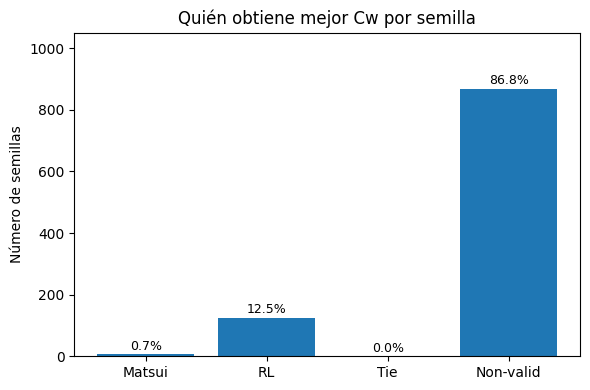

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Mejor Cw de cada método por par de máscaras
best_matsui = (
    df_matsui
    .groupby(["seed_alpha0_hex", "seed_beta0_hex"])["cw_total"]
    .min()
    .reset_index()
    .rename(columns={"cw_total": "cw_matsui"})
)

best_rl = (
    df_attack_ml
    .groupby(["seed_alpha0_hex", "seed_beta0_hex"])["cw_total_teorico_ml"]
    .min()
    .reset_index()
    .rename(columns={"cw_total_teorico_ml": "cw_rl"})
)

# 2) Emparejar por máscaras iniciales
df_comp = best_matsui.merge(
    best_rl,
    on=["seed_alpha0_hex", "seed_beta0_hex"],
    how="inner",
)

# 3) Determinar ganador
cw_m = df_comp["cw_matsui"].to_numpy()
cw_r = df_comp["cw_rl"].to_numpy()

winner = np.full(len(df_comp), "Non-valid", dtype=object)  # por defecto

# Valores no válidos: 0 ó 100
m_invalid = (cw_m == 0) | (cw_m == 100)
r_invalid = (cw_r == 0) | (cw_r == 100)

# Ambos no válidos -> Non-valid (ya está por defecto)
both_invalid = m_invalid & r_invalid

# Resto: al menos uno válido
mask_rest = ~both_invalid

# Para comparar, tratamos los no válidos como un número enorme
BIG = 10**9
m_eff = np.where(mask_rest & m_invalid, BIG, cw_m)
r_eff = np.where(mask_rest & r_invalid, BIG, cw_r)

# Gana el válido más pequeño
winner[mask_rest & (r_eff < m_eff)] = "RL"
winner[mask_rest & (m_eff < r_eff)] = "Matsui"

# Empate real: ambos válidos e iguales
mask_tie_real = (
    mask_rest &
    ~m_invalid & ~r_invalid &
    (cw_m == cw_r)
)
winner[mask_tie_real] = "Tie"

df_comp["winner"] = winner

# 4) Estadísticas y porcentajes
counts = df_comp["winner"].value_counts()
total  = len(df_comp)

n_matsui   = counts.get("Matsui", 0)
n_rl       = counts.get("RL", 0)
n_tie      = counts.get("Tie", 0)
n_nonvalid = counts.get("Non-valid", 0)

pct_matsui   = 100 * n_matsui / total
pct_rl       = 100 * n_rl / total
pct_tie      = 100 * n_tie / total
pct_nonvalid = 100 * n_nonvalid / total

print(f"Total semillas comparadas : {total}")
print(f"Matsui mejor      : {n_matsui} ({pct_matsui:.2f}%)")
print(f"RL mejor          : {n_rl} ({pct_rl:.2f}%)")
print(f"Empate (válido)   : {n_tie} ({pct_tie:.2f}%)")
print(f"Non-valid (0/100) : {n_nonvalid} ({pct_nonvalid:.2f}%)")

# 5) Gráfico de barras
labels = ["Matsui", "RL", "Tie", "Non-valid"]
values = [n_matsui, n_rl, n_tie, n_nonvalid]
pcts   = [pct_matsui, pct_rl, pct_tie, pct_nonvalid]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, values)

for bar, pct in zip(bars, pcts):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f"{pct:.1f}%",
        ha="center", va="bottom", fontsize=9
    )

plt.ylabel("Número de semillas")
plt.title("Quién obtiene mejor Cw por semilla")
plt.ylim(0, total * 1.05)
plt.tight_layout()
plt.show()


In [66]:
s0 = (78, 189, 82, 57, 0, 0)

# Ver las Q para ese estado
print("Q(s0) =", agent.Q.get(s0))
print("Acciones posibles desde s0:", env.actions(s0))


Q(s0) = None
Acciones posibles desde s0: [90, 91, 92, 93, 94]
